# Aero Solver Usage Tutorial

This notebook is a practical tutorial for each solver or wrapper individually.

It covers, for each tool:
- single-airfoil single-case usage
- batched usage for multiple airfoils and Reynolds values
- extracting data from outputs
- plotting results
- tuple or double-key style indexing where applicable

## 1) Common Setup

In [1]:
import os
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)

def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for parent in [start, *start.parents]:
        if (parent / "numfoil").exists() and (parent / "GADes").exists():
            return parent
    raise RuntimeError("Could not locate workspace root containing numfoil/ and GADes/")

REPO_ROOT = find_repo_root()
for extra_path in [
    REPO_ROOT / "numfoil" / "src",
    REPO_ROOT / "GADes" / "src",
    REPO_ROOT / "NeuralFoil",
]:
    extra_path_str = str(extra_path)
    if extra_path_str not in sys.path:
        sys.path.insert(0, extra_path_str)

print(f"Repo root: {REPO_ROOT}")

Repo root: c:\GitRepos\AAP


In [19]:
from numfoil.geometry.airfoil import NACA4Airfoil, KulfanAirfoil

def make_airfoil_catalog() -> dict[str, KulfanAirfoil]:
    catalog = {}
    for code in ["0012", "2412", "4412"]:
        base = NACA4Airfoil(code)
        kulfan = KulfanAirfoil.from_coordinate_array(
            base.points,
            n_coefficients=8,
            name=f"KF_NACA{code}"
        )
        catalog[kulfan.name] = kulfan
    return catalog

def write_selig_dat(points: np.ndarray, filepath: str) -> None:
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    with open(filepath, "w", encoding="utf-8") as handle:
        handle.write("airfoil\n")
        for x, y in pts:
            handle.write(f"{x:.8f} {y:.8f}\n")

def cleanup_legacy_outputs(dat_name: str) -> None:
    for pattern in [
        f"Polar_{dat_name}*",
        f"Cp_{dat_name}*",
        f"Dump_{dat_name}*",
        f"Alfa_L_0_{dat_name}*",
    ]:
        for leftover in Path.cwd().glob(pattern):
            try:
                leftover.unlink()
            except OSError:
                pass

def kulfan_dict_from_airfoil(airfoil: KulfanAirfoil) -> dict[str, np.ndarray | float]:
    p = np.asarray(airfoil.parameters, dtype=float).reshape(-1)
    if p.size != 18:
        raise ValueError(f"Expected 18 Kulfan parameters, got {p.size}")
    return {
        "upper_weights": p[:8],
        "lower_weights": p[8:16],
        "leading_edge_weight": float(p[16]),
        "TE_thickness": float(p[17]),
    }

airfoil_catalog = make_airfoil_catalog()
batch_names = ["KF_NACA0012", "KF_NACA2412"]
batch_airfoils = [airfoil_catalog[name] for name in batch_names]

alpha_case = np.array([4.0], dtype=float)
re_case = np.array([1.0e6], dtype=float)
alphas_grid = np.arange(-5.0, 18.0, 0.5, dtype=float)
reynolds_grid = np.array([1.0e5, 3.0e5, 7.0e5, 1.0e6, 3.0e6, 7.0e6], dtype=float)

print("Available tutorial airfoils:", list(airfoil_catalog.keys()))
print("Single case:\n     alpha = ", float(alpha_case[0]), "\n     Re = ", float(re_case[0]))
print("Grid sizes [airfoils, Re, alpha]:", len(batch_airfoils), len(reynolds_grid), len(alphas_grid))

Available tutorial airfoils: ['KF_NACA0012', 'KF_NACA2412', 'KF_NACA4412']
Single case:
     alpha =  4.0 
     Re =  1000000.0
Grid sizes: 2 2 5


## 2) numfoil.aero.xfoil.xfoil.XFoil

This is the modern XFOIL class wrapper that returns `AeroResults`.

- Single case: one airfoil, one alpha, one Reynolds
- Batch case: multiple airfoils and Reynolds values in one call

In [3]:
try:
    from numfoil.aero.xfoil.xfoil import XFoil
    HAS_XFOIL_CLASS = True
except Exception as exc:
    HAS_XFOIL_CLASS = False
    print(f"XFoil class wrapper unavailable: {exc}")

if HAS_XFOIL_CLASS:
    xf_solver = XFoil(iter=80)
    xf_single = xf_solver.analyze(
        airfoil=airfoil_catalog["KF_NACA2412"],
        alphas=alpha_case,
        reynolds=re_case,
        label="KF_NACA2412"
    )
    display(xf_single.to_dataframe())

XFOIL: 1 session, 1 alpha each
  [1/1] Re = 1.00e+06 ... done  (0.3s elapsed)


,Re,alpha,CL,CD,CDp,CM,Top_Xtr,Bot_Xtr
0,1000000.0,4.0,0.7083,0.00703,0.00234,-0.0569,0.3811,1.0


    """breakdown of result indexing:
    To first index data for desired airfoil using the label key:

    >>> naca2412_results = xf_batch["KF_NACA2412"]

    Double-key extraction via (airfoil -> case key)
    You can either use method calling to apply filters, then index the result:

    >>> xf_cl_curve = naca2412_results.polar(Re=1.0e6)["CL"]

    Or first index the data, then apply filters via dict-like indexing:

    >>> xf_cl_curve = naca2412_results.polar["CL"][1.0e6]

    The same works for Cp and H profiles, but with two keys (alpha and Re) instead of one (Re):

    >>> naca2412_cp_data = naca2412_results.cp["Cp"]
    >>> naca2412_h = naca2412_results.dump["H"]
    >>> naca2412_cp_alpha_4_re_1e6 = naca2412_cp_data[(4.0, 1000000.0)]
    >>> naca2412_h_alpha_4_re_1e6 = naca2412_h[(4.0, 1000000.0)]
    """

In [32]:
if HAS_XFOIL_CLASS:
    xf_batch = xf_solver.analyze(
        airfoil=batch_airfoils,
        alphas=alphas_grid,
        reynolds=reynolds_grid,
    )
    print('-----------------------------------')
    print("Batch labels:", xf_batch.airfoil_labels)

    # two different ways of accessing the same data:
    # 1. use a method call on the specific data object to apply a filter, then index the result
    print("CL curve shape (alpha sweep at Re=1e6):", xf_batch["KF_NACA2412"].polar(Re=1.0e6)["CL"].shape)
    # 2. First index the desired data, then use dict-like indexing to apply a filter
    print("CL curve shape (alpha sweep at Re=1e6):", xf_batch["KF_NACA2412"].polar["CL"][1.0e6].shape)

    # same for Cp and H profiles, but with two keys (alpha and Re) instead of one (Re)
    print("Cp profile shape (alpha=4, Re=1e6):", xf_batch["KF_NACA2412"].cp["Cp"][(4.0, 1000000.0)].shape)
    print("Cp profile shape (alpha=4, Re=1e6):", xf_batch["KF_NACA2412"].cp(alpha=4.0, Re=1.0e6)["Cp"].shape)

    # dict indexing returns itself a dict, where every combinatoin of alpha and Re is a key
    print("Cp keys:", xf_batch["KF_NACA2412"].cp["Cp"].keys())
    # method calling with alpha and Re directly returns a new instance of
    # results with applied filters.
    print("Cp keys:", xf_batch["KF_NACA2412"].cp(alpha=4.0, Re=1.0e6))


    print("H profile shape (alpha=4, Re=1e6):", xf_batch["KF_NACA2412"].dump["H"][(4.0, 1000000.0)].shape)
    display(xf_batch["KF_NACA2412"].to_dataframe().head())

-----------------------------------
Batch labels: ['KF_NACA0012', 'KF_NACA2412']
CL curve shape (alpha sweep at Re=1e6): (5,)
CL curve shape (alpha sweep at Re=1e6): (5,)
Cp profile shape (alpha=4, Re=1e6): (199,)
Cp profile shape (alpha=4, Re=1e6): (199,)
Cp keys: dict_keys([(-2.0, 300000.0), (-2.0, 1000000.0), (0.0, 300000.0), (0.0, 1000000.0), (2.0, 300000.0), (2.0, 1000000.0), (4.0, 300000.0), (4.0, 1000000.0), (6.0, 300000.0), (6.0, 1000000.0)])
Cp keys: CpData(1 entries, Re=[1M], 1 α)
H profile shape (alpha=4, Re=1e6): (225,)


,Re,alpha,CL,CD,CDp,CM,Top_Xtr,Bot_Xtr
0,300000.0,-2.0,0.0196,0.00899,0.00352,-0.0581,0.9022,0.5288
1,300000.0,0.0,0.2254,0.00780,0.00323,-0.0497,0.7976,0.9295
2,300000.0,2.0,0.5108,0.00848,0.00314,-0.0616,0.6544,1.0000
3,300000.0,4.0,0.6985,0.00970,0.00376,-0.0541,0.5155,1.0000
4,300000.0,6.0,0.8840,0.01167,0.00523,-0.0466,0.3513,1.0000


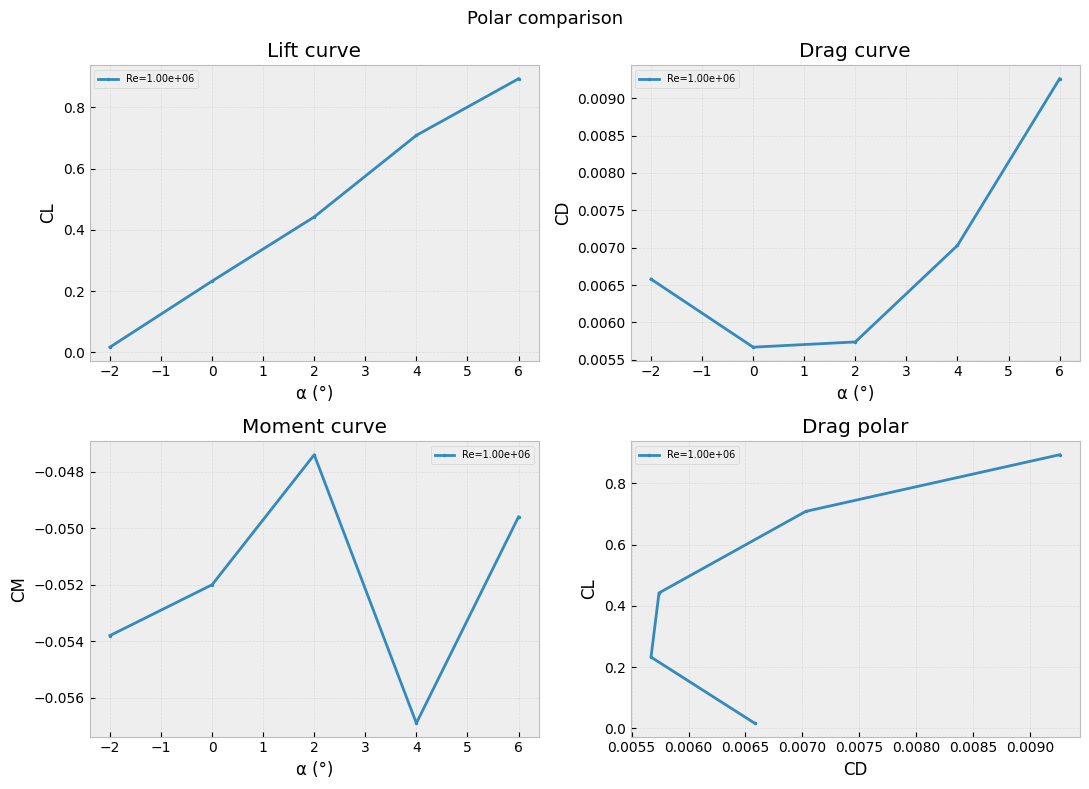

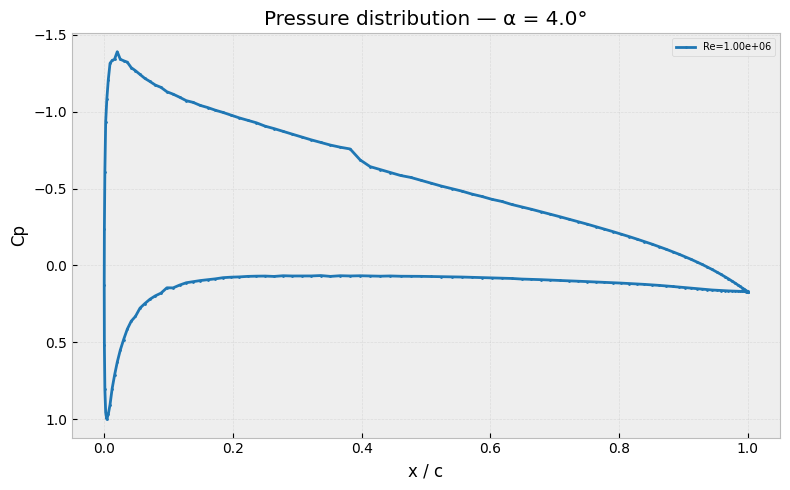

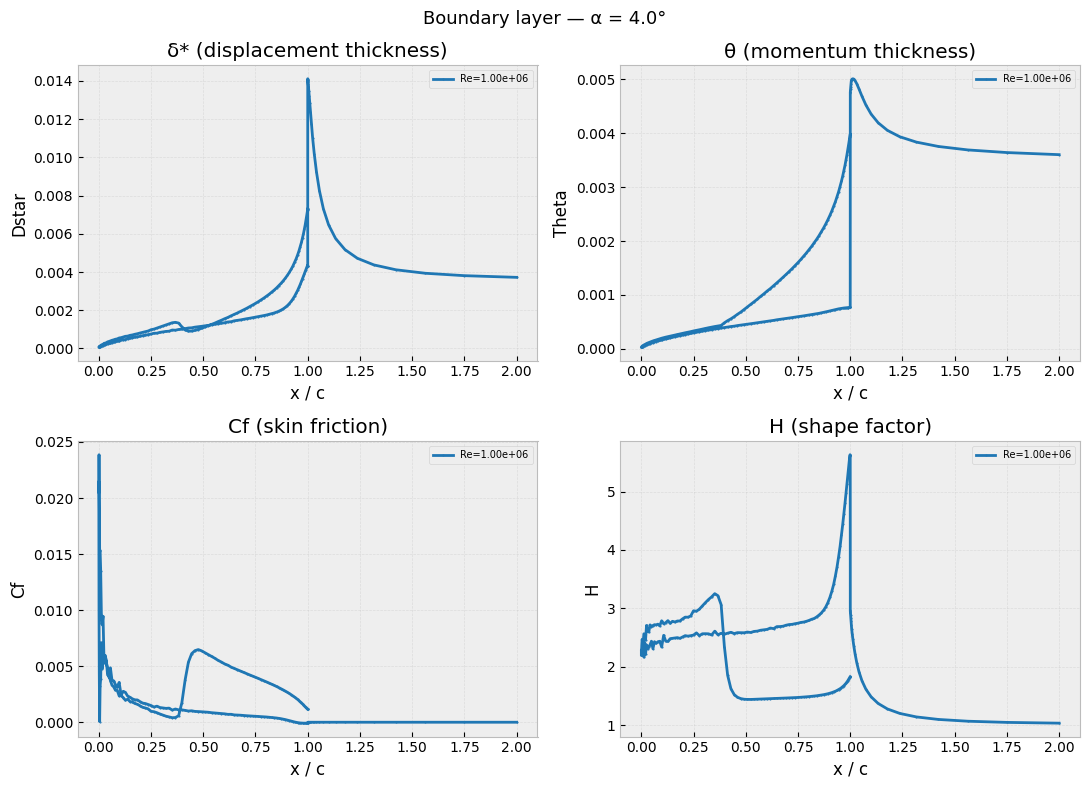

In [5]:
if HAS_XFOIL_CLASS:
    xf_child = xf_batch["KF_NACA2412"]
    xf_child.polar.plot(Re=1.0e6)
    xf_child.cp.plot(alpha=4.0, Re=1.0e6)
    xf_child.dump.plot(alpha=4.0, Re=1.0e6)

## 3) numfoil.aero.neuralfoil.neuralfoil_wrapper.NeuralFoil

This wrapper follows the same high-level API as `XFoil` and also returns `AeroResults`.

In [6]:
try:
    from numfoil.aero.neuralfoil.neuralfoil_wrapper import NeuralFoil as NumfoilNeuralFoil
    HAS_NUMFOIL_NF = True
except Exception as exc:
    HAS_NUMFOIL_NF = False
    print(f"numfoil NeuralFoil wrapper unavailable: {exc}")

if HAS_NUMFOIL_NF:
    nf_solver = NumfoilNeuralFoil(model_size="xxxlarge")
    nf_single = nf_solver.analyze(
        airfoil=airfoil_catalog["KF_NACA2412"],
        alphas=alpha_case,
        reynolds=re_case,
        batch_size=np.inf,
        label="KF_NACA2412"
    )
    display(nf_single.to_dataframe())

NeuralFoil: batched inference (1 Re x 1 alpha = 1 cases), chunk=1


,Re,alpha,CL,CD,CM,Top_Xtr,Bot_Xtr,analysis_confidence
0,1000000.0,4.0,0.708417,0.006948,-0.057294,0.394203,1.0,0.973889


In [7]:
if HAS_NUMFOIL_NF:
    nf_batch = nf_solver.analyze(
        airfoil=batch_airfoils,
        alphas=alphas_grid,
        reynolds=reynolds_grid,
        batch_size=np.inf,
    )

    print("Batch labels:", nf_batch.airfoil_labels)
    nf_child = nf_batch["KF_NACA2412"]

    # Double-key extraction via (airfoil -> case key)
    # Note: this wrapper currently provides polar + dump outputs.
    nf_cl_curve = nf_child.polar(Re=1.0e6)["CL"]
    nf_h_profile = nf_child.dump["H"][(4.0, 1000000.0)]

    print("CL curve shape (alpha sweep at Re=1e6):", np.asarray(nf_cl_curve).shape)
    print("H profile shape (alpha=4, Re=1e6):", np.asarray(nf_h_profile).shape)
    display(nf_child.to_dataframe().head())

NeuralFoil: mega-batch inference (2 foils x 2 Re x 5 alpha = 20 cases)
Batch labels: ['KF_NACA0012', 'KF_NACA2412']
CL curve shape (alpha sweep at Re=1e6): (5,)
H profile shape (alpha=4, Re=1e6): (64,)


,Re,alpha,CL,CD,CM,Top_Xtr,Bot_Xtr,analysis_confidence
0,300000.0,-2.0,0.021594,0.009038,-0.058794,0.900972,0.526626,0.970034
1,300000.0,0.0,0.223074,0.007820,-0.049732,0.800930,0.919660,0.979747
2,300000.0,2.0,0.512324,0.008470,-0.062401,0.671965,1.000000,0.983460
3,300000.0,4.0,0.694910,0.009621,-0.053965,0.524117,1.000000,0.979255
4,300000.0,6.0,0.881546,0.011611,-0.046312,0.345884,1.000000,0.976157


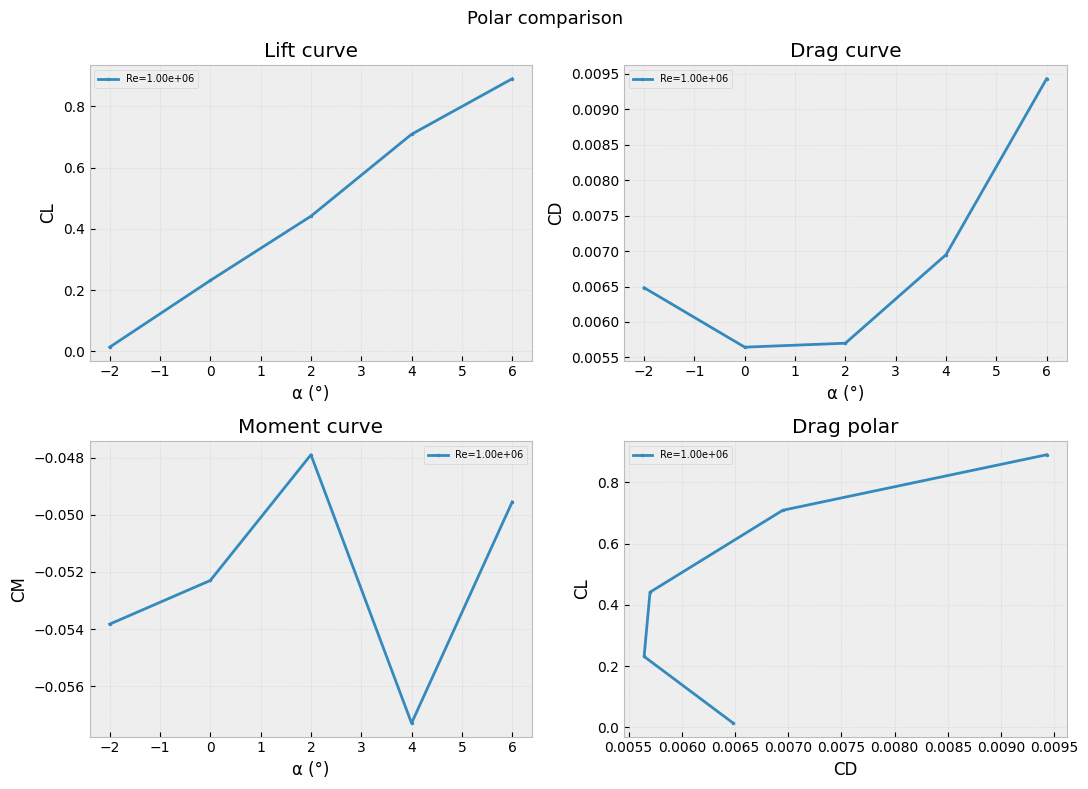

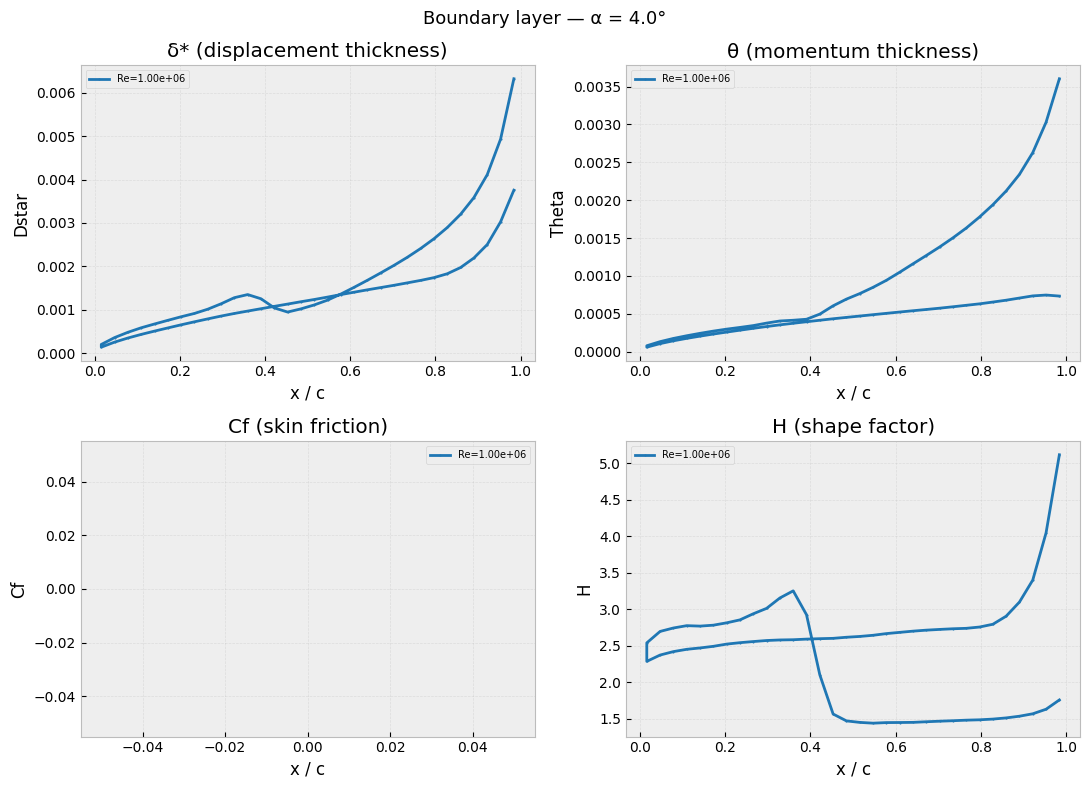

In [8]:
if HAS_NUMFOIL_NF:
    nf_child = nf_batch["KF_NACA2412"]
    nf_child.polar.plot(Re=1.0e6)
    nf_child.dump.plot(alpha=4.0, Re=1.0e6)

## 4) numfoil.aero.xfoil.xfoil_wrapper (legacy function API)

This wrapper returns plain dictionaries, not `AeroResults`.

- Single case is direct
- Multi-airfoil + multi-Re workflow is done with explicit loops

In [9]:
try:
    from numfoil.aero.xfoil import xfoil_wrapper as xw
    HAS_XFOIL_LEGACY = True
except Exception as exc:
    HAS_XFOIL_LEGACY = False
    print(f"legacy xfoil_wrapper unavailable: {exc}")

if HAS_XFOIL_LEGACY:
    foil = airfoil_catalog["KF_NACA2412"]
    dat_name = "_tmp_tutorial_single_legacy.dat"
    dat_path = Path.cwd() / dat_name
    write_selig_dat(foil.points, str(dat_path))

    try:
        legacy_single_raw = xw.find_coefficients(
            dat_name,
            alpha=float(alpha_case[0]),
            Reynolds=float(re_case[0]),
            iteration=80,
            NACA=False,
            delete=True,
            PANE=False,
            GDES=False,
        )
        legacy_single_cp = xw.find_pressure_coefficients(
            dat_name,
            alpha=float(alpha_case[0]),
            Reynolds=float(re_case[0]),
            iteration=80,
            NACA=False,
            use_previous=False,
            delete=True,
            PANE=False,
            GDES=False,
        )
    finally:
        if dat_path.exists():
            dat_path.unlink()
        cleanup_legacy_outputs(dat_name)

    legacy_single_df = pd.DataFrame(
        {
            "alpha": np.asarray(legacy_single_raw.get("alpha", []), dtype=float),
            "CL": np.asarray(legacy_single_raw.get("CL", []), dtype=float),
            "CD": np.asarray(legacy_single_raw.get("CD", []), dtype=float),
            "CM": np.asarray(legacy_single_raw.get("CM", []), dtype=float),
            "Re": float(re_case[0]),
        }
    )
    display(legacy_single_df)
    print("Single-case Cp keys:", list(legacy_single_cp.keys()))

,alpha,CL,CD,CM,Re
0,4.0,0.7087,0.007,-0.057,1000000.0


Single-case Cp keys: ['x', 'y', 'Cp']


In [10]:
if HAS_XFOIL_LEGACY:
    legacy_index = {}
    legacy_frames = []

    for foil_name in batch_names:
        foil = airfoil_catalog[foil_name]
        dat_name = f"_tmp_tutorial_legacy_{foil_name}.dat"
        dat_path = Path.cwd() / dat_name
        write_selig_dat(foil.points, str(dat_path))

        try:
            for re_value in reynolds_grid:
                raw = xw.find_coefficients(
                    dat_name,
                    alpha=[float(a) for a in alphas_grid],
                    Reynolds=float(re_value),
                    iteration=80,
                    NACA=False,
                    delete=True,
                    PANE=False,
                    GDES=False,
                )
                legacy_index[(foil_name, float(re_value))] = raw

                frame = pd.DataFrame(
                    {
                        "alpha": np.asarray(raw.get("alpha", []), dtype=float),
                        "CL": np.asarray(raw.get("CL", []), dtype=float),
                        "CD": np.asarray(raw.get("CD", []), dtype=float),
                        "CM": np.asarray(raw.get("CM", []), dtype=float),
                        "Re": float(re_value),
                        "airfoil": foil_name,
                    }
                )
                legacy_frames.append(frame)
        finally:
            if dat_path.exists():
                dat_path.unlink()
            cleanup_legacy_outputs(dat_name)

    legacy_batch_df = pd.concat(legacy_frames, ignore_index=True)
    display(legacy_batch_df.head())

    # Double-key extraction from user-constructed index
    legacy_cl_curve = np.asarray(legacy_index[("KF_NACA2412", 1000000.0)]["CL"], dtype=float)
    print("Legacy CL curve shape (KF_NACA2412, Re=1e6):", legacy_cl_curve.shape)

,alpha,CL,CD,CM,Re,airfoil
0,-2.0,-0.2367,0.00875,-0.0017,300000.0,KF_NACA0012
1,0.0,0.0000,0.00768,-0.0000,300000.0,KF_NACA0012
2,2.0,0.2371,0.00875,0.0016,300000.0,KF_NACA0012
3,4.0,0.5390,0.01057,-0.0156,300000.0,KF_NACA0012
4,6.0,0.7072,0.01349,-0.0069,300000.0,KF_NACA0012


Legacy CL curve shape (KF_NACA2412, Re=1e6): (5,)


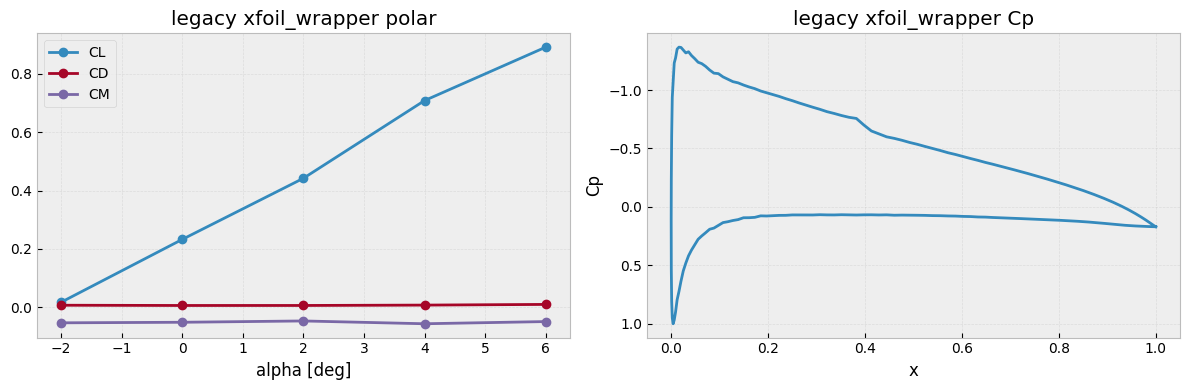

In [11]:
if HAS_XFOIL_LEGACY:
    sub = legacy_batch_df[
        (legacy_batch_df["airfoil"] == "KF_NACA2412")
        & (legacy_batch_df["Re"] == 1000000.0)
    ].sort_values("alpha")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(sub["alpha"], sub["CL"], marker="o", label="CL")
    axes[0].plot(sub["alpha"], sub["CD"], marker="o", label="CD")
    axes[0].plot(sub["alpha"], sub["CM"], marker="o", label="CM")
    axes[0].set_title("legacy xfoil_wrapper polar")
    axes[0].set_xlabel("alpha [deg]")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    if "x" in legacy_single_cp and "Cp" in legacy_single_cp:
        axes[1].plot(np.asarray(legacy_single_cp["x"], dtype=float), np.asarray(legacy_single_cp["Cp"], dtype=float))
        axes[1].invert_yaxis()
        axes[1].set_title("legacy xfoil_wrapper Cp")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("Cp")
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 5) GADes.aero.neuralfoil_module.NeuralFoilTorch

This is a torch-native module. It returns tensors (and tensor dictionaries), not `AeroResults`.

In [12]:
try:
    import torch
    from GADes.aero.neuralfoil_module import NeuralFoilTorch
    HAS_GADES_NF = True
except Exception as exc:
    HAS_GADES_NF = False
    print(f"GADes NeuralFoilTorch unavailable: {exc}")

if HAS_GADES_NF:
    nft_solver = NeuralFoilTorch(model_size="xxxlarge")
    foil = airfoil_catalog["KF_NACA2412"]

    nft_params_single = torch.as_tensor(
        np.asarray(foil.parameters, dtype=np.float32).reshape(1, -1),
        dtype=torch.float32,
    )
    nft_out_single = nft_solver.batch_eval(
        kulfan_batch=nft_params_single,
        alpha=torch.as_tensor(alpha_case.astype(np.float32)),
        Re=torch.as_tensor(re_case.astype(np.float32)),
    )

    print("Single CL tensor shape:", tuple(nft_out_single["CL"].shape))
    print("Single CL value:", float(nft_out_single["CL"][0, 0, 0].cpu().item()))

Single CL tensor shape: (1, 1, 1)
Single CL value: 0.7084169983863831


In [13]:
if HAS_GADES_NF:
    nft_params_batch = torch.as_tensor(
        np.stack([np.asarray(airfoil_catalog[name].parameters, dtype=np.float32) for name in batch_names]),
        dtype=torch.float32,
    )

    nft_out_batch = nft_solver.batch_eval(
        kulfan_batch=nft_params_batch,
        alpha=torch.as_tensor(alphas_grid.astype(np.float32)),
        Re=torch.as_tensor(reynolds_grid.astype(np.float32)),
    )

    nft_cl_grid = nft_out_batch["CL"].detach().cpu().numpy()
    nft_cd_grid = nft_out_batch["CD"].detach().cpu().numpy()
    nft_cm_grid = nft_out_batch["CM"].detach().cpu().numpy()

    foil_to_idx = {name: i for i, name in enumerate(batch_names)}
    re_to_idx = {float(r): j for j, r in enumerate(reynolds_grid.tolist())}

    # Double-key extraction using (airfoil, Re) mapped to alpha-curve
    nft_index = {
        (name, float(reynolds_grid[j])): nft_cl_grid[i, j, :]
        for i, name in enumerate(batch_names)
        for j in range(len(reynolds_grid))
    }
    nft_cl_curve = nft_index[("KF_NACA2412", 1000000.0)]

    print("Batch CL grid shape [B, R, A]:", nft_cl_grid.shape)
    print("Extracted CL curve shape:", np.asarray(nft_cl_curve).shape)

Batch CL grid shape [B, R, A]: (2, 2, 5)
Extracted CL curve shape: (5,)


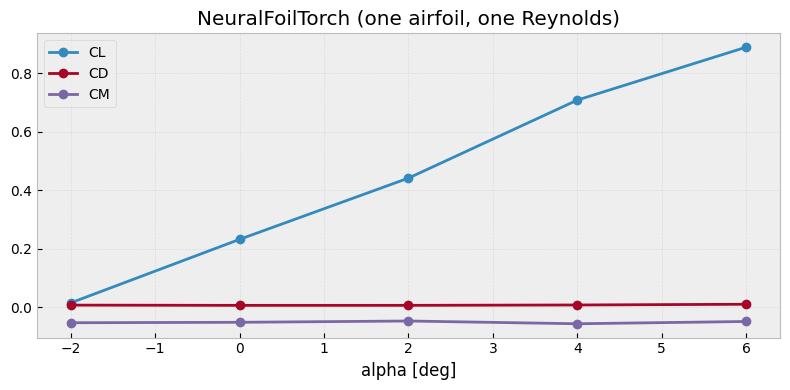

In [14]:
if HAS_GADES_NF:
    i = foil_to_idx["KF_NACA2412"]
    j = re_to_idx[1000000.0]

    plt.figure(figsize=(8, 4))
    plt.plot(alphas_grid, nft_cl_grid[i, j, :], marker="o", label="CL")
    plt.plot(alphas_grid, nft_cd_grid[i, j, :], marker="o", label="CD")
    plt.plot(alphas_grid, nft_cm_grid[i, j, :], marker="o", label="CM")
    plt.title("NeuralFoilTorch (one airfoil, one Reynolds)")
    plt.xlabel("alpha [deg]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 6) vanilla neuralfoil package

This is the direct package API (`neuralfoil.get_aero_from_kulfan_parameters`).

For batched multi-airfoil + multi-Re usage, we tile inputs into one flattened call.

In [15]:
try:
    import neuralfoil as nf
    HAS_VANILLA_NF = True
except Exception as exc:
    HAS_VANILLA_NF = False
    print(f"vanilla neuralfoil unavailable: {exc}")

if HAS_VANILLA_NF:
    foil = airfoil_catalog["KF_NACA2412"]
    van_single = nf.get_aero_from_kulfan_parameters(
        kulfan_parameters=kulfan_dict_from_airfoil(foil),
        alpha=alpha_case,
        Re=re_case,
        model_size="xxxlarge",
    )

    print("Single CL shape:", np.asarray(van_single["CL"]).shape)
    print("Single CL value:", float(np.asarray(van_single["CL"]).reshape(-1)[0]))

Single CL shape: (1,)
Single CL value: 0.7084170720659283


In [16]:
def build_vanilla_kulfan_tiled(airfoils_batch, re_arr, alpha_arr):
    rr, aa = np.meshgrid(np.asarray(re_arr, dtype=float), np.asarray(alpha_arr, dtype=float), indexing="ij")
    re_flat = rr.reshape(-1)
    alpha_flat = aa.reshape(-1)
    n_per_foil = len(re_flat)

    upper_rows = []
    lower_rows = []
    for coef_i in range(8):
        upper_rows.append(np.concatenate([np.full(n_per_foil, float(np.asarray(f.parameters)[coef_i])) for f in airfoils_batch]))
        lower_rows.append(np.concatenate([np.full(n_per_foil, float(np.asarray(f.parameters)[8 + coef_i])) for f in airfoils_batch]))

    kulfan_tiled = {
        "upper_weights": np.stack(upper_rows, axis=0),
        "lower_weights": np.stack(lower_rows, axis=0),
        "leading_edge_weight": np.concatenate([np.full(n_per_foil, float(np.asarray(f.parameters)[16])) for f in airfoils_batch]),
        "TE_thickness": np.concatenate([np.full(n_per_foil, float(np.asarray(f.parameters)[17])) for f in airfoils_batch]),
    }

    re_tiled = np.tile(re_flat, len(airfoils_batch))
    alpha_tiled = np.tile(alpha_flat, len(airfoils_batch))
    return kulfan_tiled, re_tiled, alpha_tiled

if HAS_VANILLA_NF:
    van_kulfan_tiled, van_re_tiled, van_alpha_tiled = build_vanilla_kulfan_tiled(batch_airfoils, reynolds_grid, alphas_grid)

    van_batch = nf.get_aero_from_kulfan_parameters(
        kulfan_parameters=van_kulfan_tiled,
        alpha=van_alpha_tiled,
        Re=van_re_tiled,
        model_size="xxxlarge",
    )

    n_foils = len(batch_names)
    n_re = len(reynolds_grid)
    n_alpha = len(alphas_grid)

    van_cl_grid = np.asarray(van_batch["CL"], dtype=float).reshape(n_foils, n_re, n_alpha)
    van_cd_grid = np.asarray(van_batch["CD"], dtype=float).reshape(n_foils, n_re, n_alpha)
    van_cm_grid = np.asarray(van_batch["CM"], dtype=float).reshape(n_foils, n_re, n_alpha)

    # Double-key extraction using (airfoil, Re)
    van_index = {
        (name, float(reynolds_grid[j])): van_cl_grid[i, j, :]
        for i, name in enumerate(batch_names)
        for j in range(len(reynolds_grid))
    }
    van_cl_curve = van_index[("KF_NACA2412", 1000000.0)]

    print("Batch CL grid shape [B, R, A]:", van_cl_grid.shape)
    print("Extracted CL curve shape:", np.asarray(van_cl_curve).shape)

Batch CL grid shape [B, R, A]: (2, 2, 5)
Extracted CL curve shape: (5,)


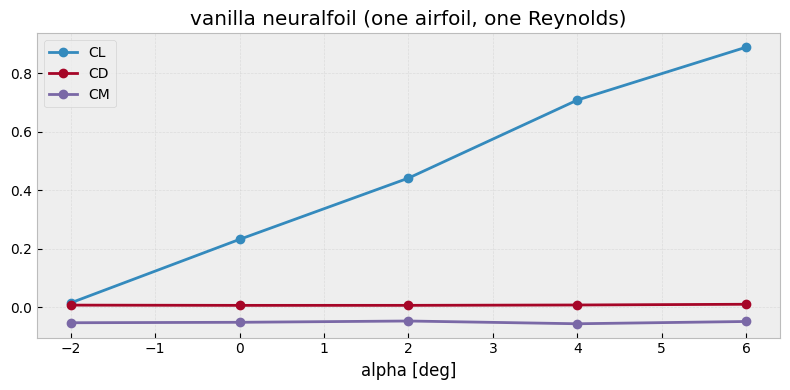

In [17]:
if HAS_VANILLA_NF:
    i = batch_names.index("KF_NACA2412")
    j = int(np.where(np.asarray(reynolds_grid, dtype=float) == 1000000.0)[0][0])

    plt.figure(figsize=(8, 4))
    plt.plot(alphas_grid, van_cl_grid[i, j, :], marker="o", label="CL")
    plt.plot(alphas_grid, van_cd_grid[i, j, :], marker="o", label="CD")
    plt.plot(alphas_grid, van_cm_grid[i, j, :], marker="o", label="CM")
    plt.title("vanilla neuralfoil (one airfoil, one Reynolds)")
    plt.xlabel("alpha [deg]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7) Notes

- The modern wrappers (`XFoil`, `NeuralFoil`) return `AeroResults` with rich indexing and plotting built in.
- The legacy wrapper and direct neural network APIs return raw dictionaries or tensors; tuple indexing is user-defined for convenience.
- For reproducibility, keep alpha and Reynolds arrays explicit and typed as float arrays.
- If a section reports an unavailable import, install dependencies for that solver and rerun that section.